### Import and reading data

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import os
import ctypes

# Force the dynamic linker to find libR.so before rpy2 tries to load
try:
    ctypes.CDLL('/usr/lib/R/lib/libR.so', mode=ctypes.RTLD_GLOBAL)
except Exception as e:
    print(f"Manual link failed: {e}")

os.environ['R_HOME'] = '/usr/lib/R'
os.environ['LD_LIBRARY_PATH'] = '/usr/lib/R/lib'

Manual link failed: Could not find module 'c:\usr\lib\R\lib\libR.so' (or one of its dependencies). Try using the full path with constructor syntax.


In [5]:
import os
import glob
from itertools import product
import numpy as np
import graphical_sampling as gs
import pandas as pd
import pickle
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities
import numpy as np
import pandas as pd



In [6]:
os.getcwd()
# os.chdir("/home/bardia/graphical-sampling")
# os.chdir("/home/bardia/graphical-sampling/simulations")
# os.chdir('/config/ws/graphical-sampling/simulations')
os.chdir('/Users/Apc/graphical-sampling/simulations')

In [7]:
os.getcwd()
os.chdir('/Users/Apc/graphical-sampling/simulations')
os.getcwd()


'c:\\Users\\Apc\\graphical-sampling\\simulations'

In [8]:
import os
import pandas as pd
import numpy as np

# Assuming inclusion_probabilities is defined elsewhere or imported
# from your package
files = ["aggregated.csv", "regular.csv", "meuse.csv", "swiss.csv"]

def popus(n, path="populations/real"):
    dfs = {} # Better to define inside to keep it clean
    for f in files:
        full_path = os.path.join(path, f)
        if not os.path.exists(full_path):
            print(f"Warning: {full_path} not found.")
            continue
            
        df = pd.read_csv(full_path)
        N_pop = len(df)
        name = f.replace('.csv', '')
        
        # Equal Probabilities (Standard for all)
        pik_ep = np.repeat(n / N_pop, N_pop)
        
        if f in ["aggregated.csv", "regular.csv"]:
            coords = df.to_numpy()
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'z'      : np.ones(N_pop) # Placeholder if z is missing
            })

        elif f == "meuse.csv":
            coords = df[['x', 'y']].to_numpy()
            # Unequal Probabilities (UP)
            pik_up = inclusion_probabilities(df['copper'].to_numpy().copy(), n)
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'pik_up' : pik_up,
                'z'      : df['cadmium']
            })

        elif f == "swiss.csv":
            coords = df[['x', 'y']].to_numpy()
            AREA = df['AREA'].to_numpy().clip(5, 100)
            pik_up = inclusion_probabilities(AREA.copy(), n)
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'pik_up' : pik_up,
                'z'      : df['AREA_A']
            })
            
    return dfs

In [9]:
import numpy as np
import pandas as pd

def rotate_population(df, alpha_degrees):
    # Convert angle to radians
    alpha_rad = np.radians(alpha_degrees)
    
    # Rotation Matrix components
    cos_a = np.cos(alpha_rad)
    sin_a = np.sin(alpha_rad)
    
    # Extract coordinates
    x = df['coord_x'].values
    y = df['coord_y'].values
    
    # Apply Rotation:
    # x' = x*cos(a) - y*sin(a)
    # y' = x*sin(a) + y*cos(a)
    df['coord_x'] = x * cos_a - y * sin_a
    df['coord_y'] = x * sin_a + y * cos_a
    
    return df

# Example use: Rotate 45 degrees
# df_rotated = rotate_population(df.copy(), 45)

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def check_inclusions(design, plot=True, title="FIP Deviation"):
    """
    Performs a statistical diagnostic on the design to ensure 
    Inclusion Probabilities (FIP) are perfectly preserved.
    """
    # 1. Extract Data
    empirical_fip = design.fip 
    target_fip = design.pop.inclusions
    diff = empirical_fip - target_fip
    max_dev = np.abs(diff).max()

    # 2. Print Summary
    print(f"--- Inclusion Probability Diagnostic ---")
    print(f"Total Design Mass: {empirical_fip.sum():.6f} (Target: {design.pop.n})")
    print(f"Max Absolute Deviation: {max_dev:.2e}")
    print(f"Mean Absolute Deviation: {np.abs(diff).mean():.2e}")

    # 3. Validation Logic
    if np.allclose(empirical_fip, target_fip, atol=1e-6):
        print("✅ SUCCESS: Inclusion probabilities are perfectly preserved!")
    else:
        fixed_count = len(design.order.fixed_ids)
        print(f"❌ WARNING: Significant deviation! Frozen units: {fixed_count}")

    # 4. Optional Plotting
    if plot:
        plt.figure(figsize=(10, 2))
        plt.plot(diff, color='red', lw=1, alpha=0.7)
        plt.title(f"{title} (Max Dev: {max_dev:.2e})")
        plt.axhline(0, color='black', lw=0.5, ls='--')
        plt.ylabel("Delta")
        plt.xlabel("Unit Index")
        plt.grid(True, alpha=0.2)
        plt.show()

# Parameters

<Axes: title={'center': 'FIP Balanced 20-Means Soft Clustering with Zones'}, xlabel='$X_1$', ylabel='$X_2$'>

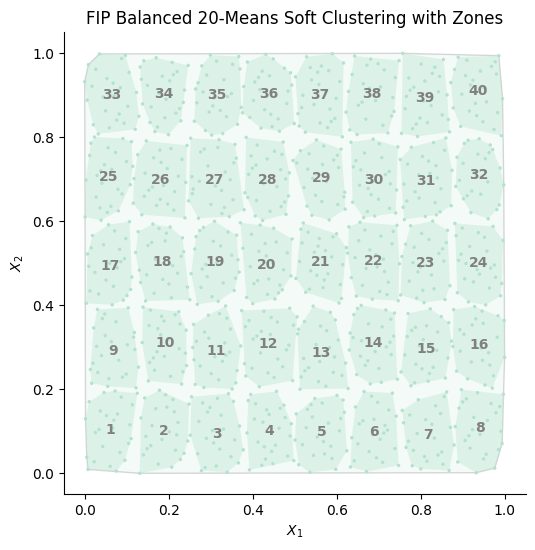

In [11]:
# --- Parameters ---
popu = 'df_regular'
ep_or_up = 'pik_ep'
n = 20
df = popus(n)[popu]
df = rotate_population(df.copy(),0)
N = len(df)

r_sample_per_cluster = 20
centroid_grid_x = 1
centroid_grid_x_zone = 9
num_zones_cluster = [100]
num_zones_sweep = [(8, 5)]
num_splits = [1]
topological = True
shift_jumps = [0,]
shuffle=False

# --- Data Preparation ---
target_df = df
coords_data = target_df[['coord_x', 'coord_y']].to_numpy()
inclusions_data = target_df[ep_or_up].to_numpy()
# np.random.seed(123)
# inclusions_data = inclusion_probabilities(np.random.random(N), n)
# print(inclusions_data)
variable_data = target_df['z'].to_numpy() if 'z' in target_df.columns else inclusions_data

# --- Population & Clustering ---
pop = gs.Population(coords_data, inclusions_data, n=n, variable=variable_data)

fbn = gs.clustering.FIPBalancedNMeans(
    n=n, 
    centroid_grid_x=centroid_grid_x, 
    r_sample_per_cluster=r_sample_per_cluster, 
    init_clust_method='expanded', 
    split_size=1
)

fbn.fit(pop)
fbn.fit_zones(num_zones=num_zones_sweep[0], mode='sweep_yx')
# fbn.fit_zones(num_zones=num_zones_cluster[0], mode='cluster')

# --- Visualization ---
fbn.plot(mode='soft')

### Pre-Process

In [12]:
# --- Parameters ---
# Re-ordered to put None and lexico_yx first (establish a strong baseline early)
all_strategies = ['None' ,'lexico_yx', 'projection', 'spiral', 'angle', 
                    'dist_from_origin', 'dist_from_centroids', 'max_coord', 'lexico_xy', 'snake', 'knight_move', 'hilbert', 'snake_refined',
                    'hilbert_strong', 'morton_grts', 'snake_staggered']
point_strategies = all_strategies
        
# point_strategies = ['knight_move', 'snake', 'lexico_xy', 'lexico_yx']
point_strategies = ['knight_move']

zone_strategies = all_strategies
                  
# zone_strategies = ['knight_move', 'snake', 'lexico_xy', 'lexico_yx']
zone_strategies = ['None']
zone_modes = ['sweep_xy', 'sweep_yx']
#zone_modes = ['cluster']
# Ensure shift_jumps is defined in your notebook before this

initial_designs = []
track = []
min_moran = float('inf') 

# Correct calculation for total iterations
num_designs = len(point_strategies) * len(zone_strategies) * len(zone_modes) * len(num_splits) * len(shift_jumps)

# Initialize Progress Bar
pbar = tqdm(product(point_strategies, zone_strategies, zone_modes, num_splits, shift_jumps), total=num_designs)

for point_strategy, zone_strategy, zone_mode, num_split, shift_jump in pbar:
    
    # Selection of zone counts
    list_of_num_zones = num_zones_cluster if zone_mode == 'cluster' else num_zones_sweep

    for num_zones in list_of_num_zones:
        # 1. Fresh Clustering
        fbn = gs.clustering.FIPBalancedNMeans(
            n=n,
            centroid_grid_x=centroid_grid_x, 
            r_sample_per_cluster=r_sample_per_cluster, 
            init_clust_method='expanded', 
            split_size=1
        )
        fbn.fit(pop)
        fbn.fit_zones(num_zones=num_zones, mode=zone_mode)
        
        # 2. Build Order
        try:
            # IMPORTANT: Set shuffle=True here to use your new Prime Phase Shift logic
            order = gs.Order.from_clusters(
                pop, 
                fbn.clusters, 
                zone_strategy=zone_strategy, 
                point_strategy=point_strategy, 
                num_splits=num_split,
                topological=topological,
                shift_jump=shift_jump,
                shuffle=shuffle,
                # THE FIX: Only pass as tuple, otherwise let it auto-calculate
                grid_dims=num_zones if isinstance(num_zones, tuple) else None,
            )

            # 3. Create Design
            design = gs.Design.from_order(pop, order)

            # 4. Evaluate Moran Index
            moran_val = design.moran[0]
            
            # --- BASELINE FIX: Print the very first valid result ---
            if len(track) == 0:
                min_moran = moran_val
                print(f"[INITIAL BASELINE] Moran: {moran_val:.6f} | ZS: {zone_strategy} | PS: {point_strategy}")

            # --- IMPROVEMENT LOGIC ---
            if moran_val < min_moran:
                min_moran = moran_val
                # Using aligned printing for clarity
                print(f"[NEW BEST] Moran: {moran_val:.6f} | ZS: {str(zone_strategy):<15} | PS: {str(point_strategy):<15} | Jump: {shift_jump}")
            
            # Show live status next to the bar
            pbar.set_postfix({"Best": f"{min_moran:.6f}"})

            initial_designs.append(design)
            track.append((moran_val, design, zone_strategy, point_strategy, zone_mode, num_zones, shift_jump))
            
        except Exception as e:
            # If everything shows nothing, comment out 'continue' and uncomment 'raise e' to see why
            continue

# --- Final Ranking Output ---
if not track:
    print("\n[ERROR] No designs were successfully generated. Check your try/except block.")
else:
    results = sorted(track, key=lambda x: x[0])
    best = results[0]

    print(f"\n{'='*40}")
    print(f"      OPTIMIZATION COMPLETE")
    print(f"{'='*40}")
    print(f"Best Moran:      {best[0]:.6f}")
    print(f"Zone Strategy:   {best[2]}")
    print(f"Point Strategy:  {best[3]}")
    print(f"Zone Mode:       {best[4]}")
    print(f"Num Zones:       {best[5]}")
    print(f"Shift Jump:      {best[6]}")
    print(f"{'='*40}")

 50%|█████     | 1/2 [00:01<00:01,  1.23s/it, Best=-0.308075]

[INITIAL BASELINE] Moran: -0.308075 | ZS: None | PS: knight_move


100%|██████████| 2/2 [00:02<00:00,  1.23s/it, Best=-0.308075]


      OPTIMIZATION COMPLETE
Best Moran:      -0.308075
Zone Strategy:   None
Point Strategy:  knight_move
Zone Mode:       sweep_xy
Num Zones:       (8, 5)
Shift Jump:      0


In [13]:
z = sorted(track, key=lambda x: x[0], reverse=False)
# Add 'jump' to the end of the unpacking list
initial_moran, initial_design, zs, ps, zm, nz, jump = z[0]
len(initial_design.all_samples_and_probs[0])
initial_design.all_samples_and_probs[1].sum()

np.float32(1.0)

In [14]:
import numpy as np

# 1. Get the empirical FIP (calculated from your repaired samples)
empirical_fip = initial_design.fip
# 2. Get the target FIP (the ones originally defined in the population)
target_fip = design.pop.inclusions

# 3. Calculate the difference
diff = empirical_fip - target_fip

# 4. Print the summary of results
print(f"--- Inclusion Probability Check ---")
print(f"Sum of Empirical FIP: {empirical_fip.sum():.4f} (Should be {design.pop.n})")
print(f"Max Absolute Deviation: {np.abs(diff).max():.2e}")
print(f"Mean Absolute Deviation: {np.abs(diff).mean():.2e}")

# Check if they are 'close enough' within a tolerance (e.g., 1e-6)
if np.allclose(empirical_fip, target_fip, atol=1e-6):
    print("SUCCESS: Inclusion probabilities are preserved!")
else:
    print("WARNING: There is a significant deviation in inclusion probabilities.")

--- Inclusion Probability Check ---
Sum of Empirical FIP: 20.0000 (Should be 20)
Max Absolute Deviation: 1.88e-09
Mean Absolute Deviation: 1.60e-09
SUCCESS: Inclusion probabilities are preserved!


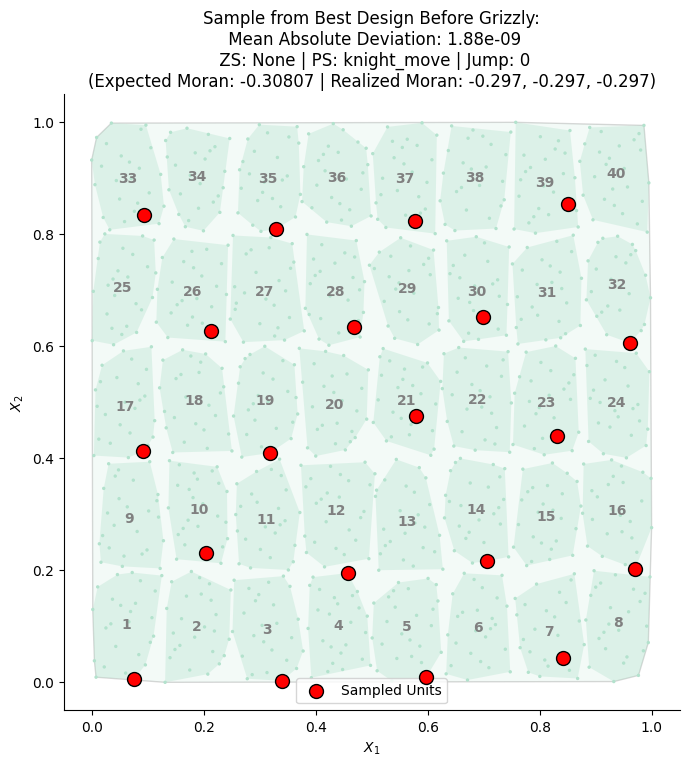

Sampled Unit Indices: [712 969 650 845  24 793 411  31 488  41  42 299 620 301 814 431 874 235
 494 556]


In [15]:
import matplotlib.pyplot as plt
from graphical_sampling.index import Moran

# 1. Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Use the best design
best_design = initial_design 

# 3. Draw the background (Clustering and Zones)
fbn.plot(mode='soft', ax=ax)

# 4. Extract a SINGLE sample (2D array: 1 row, n columns)
sample_indices_2d = best_design.sample(1)
sample_indices = sample_indices_2d[0] 

# 5. Calculate Moran for this SPECIFIC realization
# We use the Moran indexer on the current coordinates
realized_moran_tille = Moran(best_design.pop, method='tille').score(sample_indices_2d)[0]
realized_moran_raphael = Moran(best_design.pop, method='raphael').score(sample_indices_2d)[0]
realized_moran_robertson = Moran(best_design.pop, method='robertson').score(sample_indices_2d)[0]

# 6. Scatter the sampled points in Red
all_coords = best_design.pop.coords
ax.scatter(
    all_coords[sample_indices, 0], 
    all_coords[sample_indices, 1], 
    color='red', 
    s=100, 
    edgecolors='black', 
    label='Sampled Units',
    zorder=15 
)

# 7. Update title with both Expected and Realized Moran
ax.set_title(f"Sample from Best Design Before Grizzly:\n Mean Absolute Deviation: {np.abs(diff).max():.2e}\n ZS: {best[2]} | PS: {best[3]} | Jump: {shift_jump}\n(Expected Moran: {best_design.moran[0]:.5f} | Realized Moran: {realized_moran_tille:.3f}, {realized_moran_raphael:.3f}, {realized_moran_robertson:.3f})")
ax.legend()
plt.show()

print(f"Sampled Unit Indices: {sample_indices}")

In [16]:
initial_design = results[0][1]
criteria = gs.criteria.MoranCriteria()
gbfs = gs.search.GreedyBestFirstSearch([initial_design], criteria)

In [17]:
raise KeyboardInterrupt("Execution stopped by user.")

KeyboardInterrupt: Execution stopped by user.

### Save or Load

In [ ]:
import os
import pickle
from datetime import datetime

# Config
SAVE_FOLDER = "best_designs"
os.makedirs(SAVE_FOLDER, exist_ok=True)

# Metadata for filename
pop_label = getattr(gbfs.best_design.pop, 'label', 'pop').replace(" ", "_")
sample_n = gbfs.best_design.pop.n
score = gbfs.best_criteria_value
timestamp = datetime.now().strftime("%m%d_%H%M")

# Filename
filename = f"ENGINE_{pop_label}_n{sample_n}_zone{num_zones_sweep[0]}_score{score:.4f}_{timestamp}.pkl"
save_path = os.path.join(SAVE_FOLDER, filename)

# Save THE WHOLE OBJECT
with open(save_path, 'wb') as f:
    pickle.dump(gbfs, f)

print(f"✅ Grizzly Engine state saved to: {save_path}")
print(f"Current Open Set: {len(gbfs.open_set)} | Closed Set: {len(gbfs.closed_set)}")

C:\Users\Apc\AppData\Local\Temp\ipykernel_20728\1774474309.py:21: DeprecationWarning: Pickle, copy, and deepcopy support will be removed from itertools in Python 3.14.
  pickle.dump(gbfs, f)


✅ Grizzly Engine state saved to: best_designs\ENGINE_pop_n20_score-0.3081_0424_0122.pkl
Current Open Set: 180 | Closed Set: 21


In [ ]:
import os, pickle
from datetime import datetime

SAVE_FOLDER = "best_designs"
os.makedirs(SAVE_FOLDER, exist_ok=True)

pop_label = getattr(gbfs.best_design.pop, 'label', 'pop').replace(" ", "_")
score = gbfs.best_criteria_value
timestamp = datetime.now().strftime("%m%d_%H%M")

filename = f"FULL_ENGINE_{pop_label}_zone{num_zones_sweep[0]}_score{score:.4f}_{timestamp}.pkl"
save_path = os.path.join(SAVE_FOLDER, filename)

with open(save_path, 'wb') as f:
    pickle.dump(gbfs, f) # Saves EVERYTHING including the open_set

print(f"✅ Full search state saved: {save_path}")
print(f"Candidates waiting in Open Set: {len(gbfs.open_set)}")

In [ ]:
import pickle
import os

FILE_TO_LOAD = r"best_designs/ENGINE_pop_n20_score-0.3225_0424_0110.pkl" # Update this!

if os.path.exists(FILE_TO_LOAD):
    with open(FILE_TO_LOAD, 'rb') as f:
        gbfs = pickle.load(f)
    
    print(f"🚀 Grizzly resumed! Best Score: {gbfs.best_criteria_value:.6f}")
    print(f"Ready to run with {len(gbfs.open_set)} candidates in the frontier.")
else:
    print(f"❌ File not found: {FILE_TO_LOAD}")

🚀 Grizzly ENGINE is back! Loaded from: ENGINE_pop_n20_score-0.3225_zone(8, 5)_0424_0110.pkl
Current Baseline Score: -0.322472
Open Set contains 1 candidates. Ready to .run()!


In [ ]:
# srs_var = N**2 * (1-n/N) * np.var(variable)/n

# plain_flat = [
#     N,
#     n,
#     5000,
#     0,
#     np.sum(variable),
#     initial_design.nht_variance,
#     # srs_var / initial_design.nht_variance,
#     0,
#     0,
#     initial_design.density_disparity[0],
#     initial_design.density_disparity[1],
#     initial_design.voronoi[0],
#     initial_design.voronoi[1],
#     initial_design.moran[0],
#     initial_design.moran[1],
#     initial_design.local_balance[0],
#     initial_design.local_balance[1],
# ]

# print(", ".join(map(str, plain_flat)))


### GRIZZLY

In [ ]:
gbfs.run(
    max_iterations=1000,        # maximum number of GBFS search iterations (how long the algorithm explores)
    max_open_set_size=500,     # maximum number of candidate designs stored in the priority queue (search frontier)

    top_k=1,                    # number of best designs tracked during the search (best-so-far solutions)

    num_new_order_nodes=10,     # number of neighbors generated by modifying the ordering of samples
                                # (creates 20 candidate designs by changing sample order)

    num_new_exchange_nodes=0,   # number of neighbors generated using exchange moves
                                # (0 means no swapping of units between samples)

    num_clusters_range=(1,1),             # order changes are applied within up to 2 clusters
                                # (clusters are groups of zones processed together)

    num_zones_range=(1, 1),                # within a cluster, modify only 1 zone at a time

    num_changes_range=(1, 1),              # each generated neighbor performs one order modification
                                # (e.g., one swap/reposition in the sequence)

    num_zone_changes=0,         # do not reassign samples between zones (zone structure remains fixed)

    pull_strategy='random',   # rule for selecting samples during exchange operations
                                # (not used here since exchange neighbors are disabled)

    exchange_coef=.5,          # intensity of unit swapping during exchanges
                                # (irrelevant here because num_new_exchange_nodes = 0)

    num_explore=1,               # number of designs expanded per iteration
                                # (1 means purely greedy: always expand the current best design)
    window=None,
    
    n_jobs = -1
)
gbfs.initial_designs =  [gbfs.best_design]
check_inclusions(gbfs.best_design, plot=False)

Initializing Open Set from scratch...
--- Parallel GBFS: Batch=1, Workers=-1 ---
Iter     0 | Best Moran: -0.308075 | Open: 1
Iter     5 | Best Moran: -0.308075 | Open: 46
Update @    5: -0.308079 | order_change | DSize:   80 | Entp: 4.2756 | FIP Dev: 1.9e-09
Update @    6: -0.308085 | order_change | DSize:   80 | Entp: 4.2756 | FIP Dev: 1.9e-09
Update @    7: -0.308086 | order_change | DSize:   80 | Entp: 4.2756 | FIP Dev: 1.9e-09
Iter    10 | Best Moran: -0.308086 | Open: 91
Iter    15 | Best Moran: -0.308086 | Open: 136
Update @   17: -0.308096 | order_change | DSize:   80 | Entp: 4.2756 | FIP Dev: 1.9e-09
Update @   17: -0.308117 | order_change | DSize:   80 | Entp: 4.2756 | FIP Dev: 1.9e-09
Iter    20 | Best Moran: -0.308117 | Open: 181


KeyboardInterrupt: 

In [ ]:
gbfs.initial_designs =  [gbfs.best_design]

In [ ]:
# srs_var = N**2 * (1-n/N) * np.var(variable)/n
# plain_flat = [
#     N,
#     n,
#     5000,
#     0,
#     np.sum(variable),
#     float(gbfs.best_design.nht_variance),
#     # float(srs_var / gbfs.best_design.nht_variance),
#     0,
#     *map(float, gbfs.best_design.density_disparity),
#     *map(float, gbfs.best_design.voronoi),
#     *map(float, gbfs.best_design.moran),
#     *map(float, gbfs.best_design.local_balance),
# ]
# arr = np.array(plain_flat, dtype=float)
# simple = [float(x) for x in arr]
# # Example: flatten all tuples in the list
# flat = []
# for x in simple:
#     if isinstance(x, tuple):
#         flat.extend(x)
#     else:
#         flat.append(x)

# print(', '.join(str(x) for x in flat))




### Global Searching!

In [ ]:
# Use the class method (Option 2) - it is the cleanest approach
polished_start = gbfs.best_design.flatten()

# Diagnostic prints to verify the "Release"
print(f"Restricted Borders: {len(gbfs.best_design.order.fixed_ids)}")
print(f"Released Borders:   {len(polished_start.order.fixed_ids)}")

# Update the search engine state with the released design
gbfs.initial_designs = [polished_start]
gbfs.best_design = polished_start
gbfs.best_criteria_value = gbfs.criteria(polished_start)

# Now run gbfstabu.run(...) with global parameters (num_partitions=1)

Restricted Borders: 0
Released Borders:   0


In [ ]:
gbfs.run(
    max_iterations=1000,        # maximum number of GBFS search iterations (how long the algorithm explores)
    max_open_set_size=500,     # maximum number of candidate designs stored in the priority queue (search frontier)

    top_k=1,                    # number of best designs tracked during the search (best-so-far solutions)

    num_new_order_nodes=100,     # number of neighbors generated by modifying the ordering of samples
                                # (creates 20 candidate designs by changing sample order)

    num_new_exchange_nodes=0,   # number of neighbors generated using exchange moves
                                # (0 means no swapping of units between samples)

    num_clusters_range=(1,1),             # order changes are applied within up to 2 clusters
                                # (clusters are groups of zones processed together)

    num_zones_range=(1, 1),                # within a cluster, modify only 1 zone at a time

    num_changes_range=(1, 1),              # each generated neighbor performs one order modification
                                # (e.g., one swap/reposition in the sequence)

    num_zone_changes=0,         # do not reassign samples between zones (zone structure remains fixed)

    pull_strategy='largest',   # rule for selecting samples during exchange operations
                                # (not used here since exchange neighbors are disabled)

    exchange_coef=.5,          # intensity of unit swapping during exchanges
                                # (irrelevant here because num_new_exchange_nodes = 0)

    num_explore=1,               # number of designs expanded per iteration
                                # (1 means purely greedy: always expand the current best design)
    window=1,
    
    n_jobs = -1
)
check_inclusions(gbfs.best_design, plot=False)

--- Starting Parallel GBFS: Max Iterations=1000, Batch Size=1, Workers=-1 ---
Initial best criteria value: -0.3509
Iter     0/1000 | Best: -0.3509 | Open:     1 | Closed:     0 | moran: -0.3509
UpdateSimp @   35: -0.350881 | Type: order_change | struc: 1Cx1Z | DSize:   50 | Entp: 3.9120
Iter   100/1000 | Best: -0.3509 | Open:   876 | Closed:    99 | moran: -0.3509


KeyboardInterrupt: 